# FSPS mock-catalog SBI validation

This notebook validates the experimental conditional-diffusion SBI path on a mock catalog generated with the real CompoSED `FSPSBackend`.

It is a real-backend validation, not an analytic toy test.  It requires `python-fsps`, `sedpy`, `astropy`, `torch`, and `SPS_HOME` when the FSPS cache is regenerated.

## Scientific data flow

1. Draw scalar parameters from `ParameterSpace`: `zred`, `log10_mass`, `dust2`, `logzsol`, `tau_gyr`, and `age_fraction`.
2. `DelayedTauSFH` converts scalar SFH parameters into the validated tabular history required by FSPS.
3. A `Problem` binds the FSPS backend, priors, filters, units, and active-band convention.
4. `Problem.simulate` applies `10**log10_mass` because FSPS declares `PER_SOLAR_MASS`.
5. `simulate_sbi_training_set` produces noisy active-band flux vectors and AB-magnitude features.
6. Train a conditional diffusion model on the joint vector `[magnitudes, theta]`.
7. Condition on the magnitude entries, sample the parameter entries, and run generic SBI diagnostics: coverage, ranks, posterior median-vs-truth, and a single-object posterior plot.

Important audit functions live in `examples/fsps_sbi_mock_catalog_validation.py`: `build_parameter_space`, `build_problem`, `generate_fsps_mock_catalog`, and `train_diffusion_and_run_diagnostics`.

In [1]:
from pathlib import Path
import os
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
for root in candidate_roots:
    if (root / "examples" / "fsps_sbi_mock_catalog_validation.py").exists():
        PROJECT_ROOT = root
        break
else:
    raise RuntimeError("Could not locate the CompoSED project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("SPS_HOME:", os.environ.get("SPS_HOME"))

Project root: /Users/gregoire/Documents/Sedfitting/CompoSED
SPS_HOME: /Users/gregoire/Work/FSPS


In [2]:
from examples.fsps_sbi_mock_catalog_validation import run_validation

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "fsps_sbi_mock_catalog_validation_notebook"

# regenerate=False means the notebook reuses the provenance-backed FSPS cache
# if it already exists.  Set regenerate=True after changing priors, filters,
# FSPS options, or the random seed.
summary = run_validation(output_dir=OUTPUT_DIR, regenerate=False)
summary

{'estimator': 'ConditionalDiffusionEstimator',
 'device': 'mps',
 'final_train_loss': 0.5948745012283325,
 'training_seconds': 1.8563166249950882,
 'sampling_seconds': 0.0742634589842055,
 'samples_per_second': 55154.985453493966,
 'known_clamp_max_abs_error': 0.0,
 'n_train': 48,
 'n_test': 16,
 'num_samples': 256,
 'steps': 32,
 'epochs': 50,
 'mean_coverage': {'0.05': 0.03125,
  '0.10': 0.046875,
  '0.15': 0.140625,
  '0.20': 0.234375,
  '0.25': 0.265625,
  '0.30': 0.296875,
  '0.35': 0.34375,
  '0.40': 0.40625,
  '0.45': 0.4375,
  '0.50': 0.46875,
  '0.55': 0.484375,
  '0.60': 0.59375,
  '0.65': 0.640625,
  '0.70': 0.71875,
  '0.75': 0.78125,
  '0.80': 0.859375,
  '0.85': 0.921875,
  '0.90': 0.96875,
  '0.95': 0.984375},
 'median_abs_error': {'zred': 0.4019711672630217,
  'log10_mass': 0.5518969992754581,
  'dust2': 0.179273490251386,
  'logzsol': 0.18425187023610717},
 'metadata': {'schema': 'fsps_sbi_mock_catalog.native_composed.v1',
  'filter_names': ['sdss_u0', 'sdss_g0', 'sdss

## Diagnostic plots

This default run is intentionally small, so calibration should not be over-interpreted.  The useful checks here are provenance, finite posterior samples, the training/sampling timing, and whether the diagnostics clearly reveal the limited training set.

coverage_curve.png


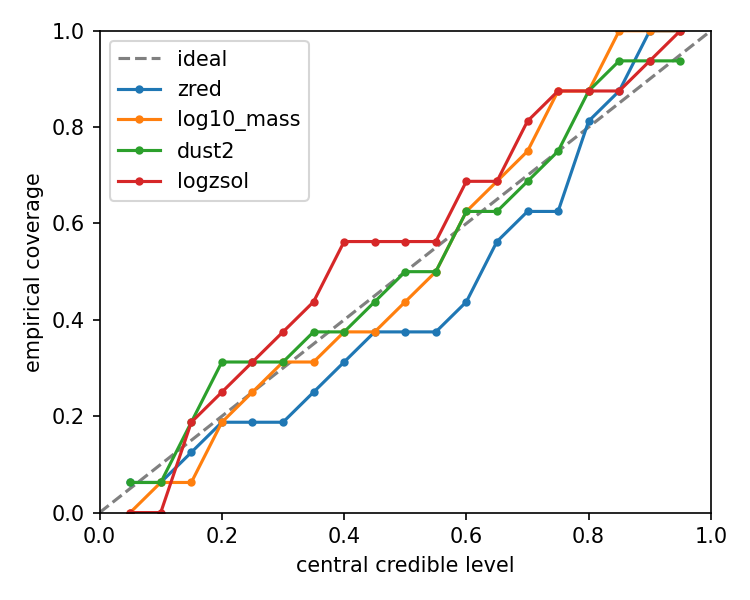

rank_histograms.png


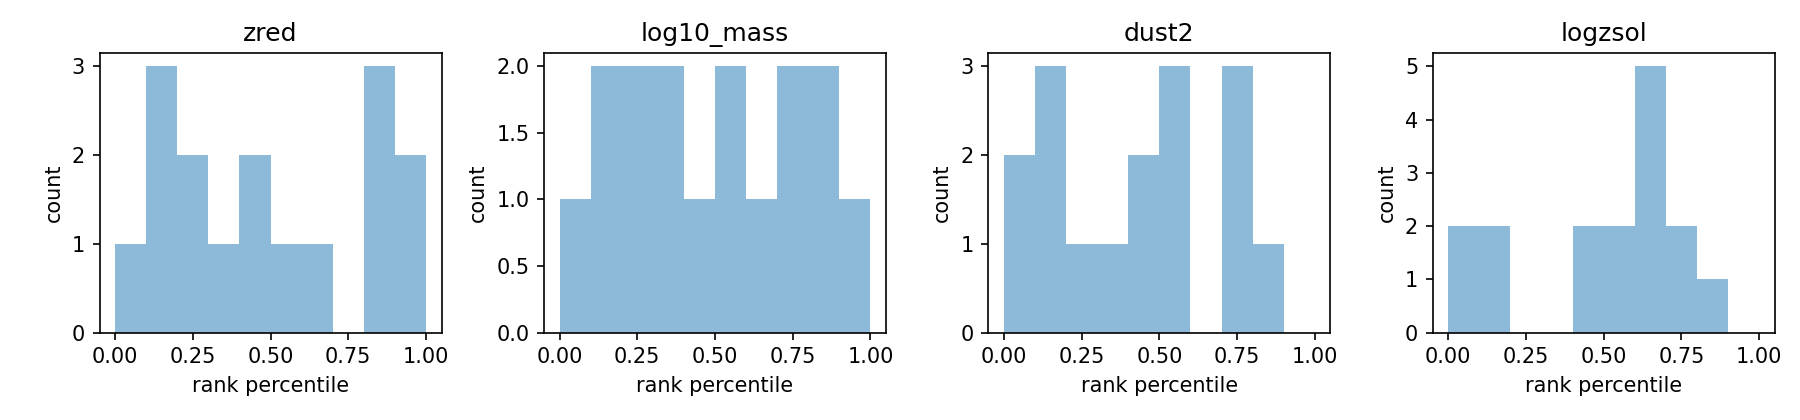

prediction_scatter.png


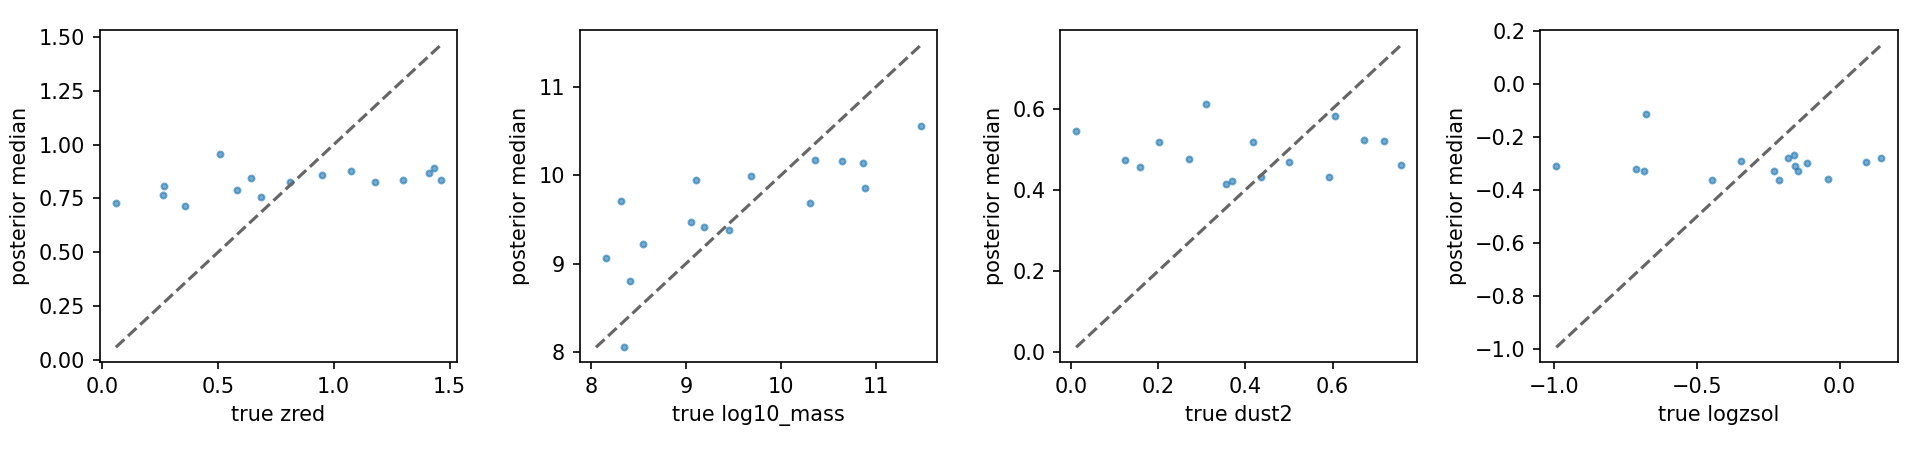

single_posterior.png


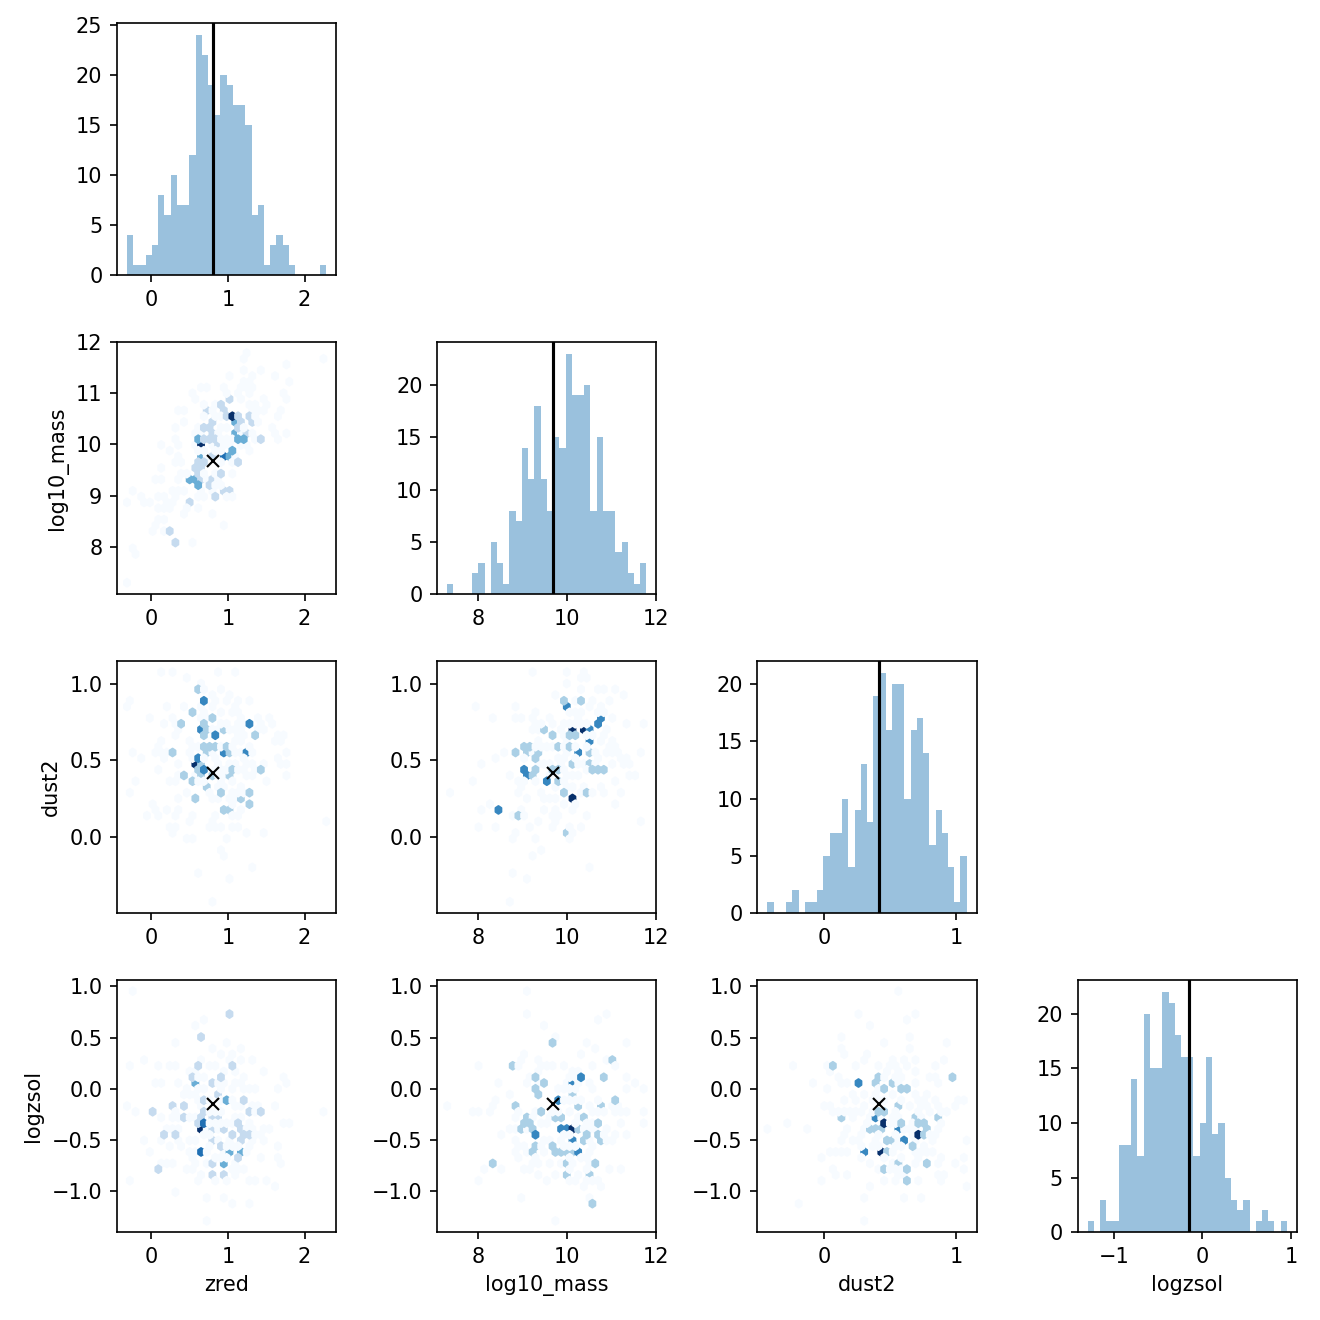

In [3]:
from IPython.display import Image, display

for filename in [
    "coverage_curve.png",
    "rank_histograms.png",
    "prediction_scatter.png",
    "single_posterior.png",
]:
    path = OUTPUT_DIR / "diagnostics" / filename
    print(filename)
    display(Image(filename=str(path)))